## Import Libraries

In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## Loading Data 

In [291]:
df = pd.read_csv('credit_card.csv')
df.head(10)

,transaction_amount,transaction_hour,distance_from_home_km,distance_from_last_transaction_km,ratio_to_median_purchase,repeat_retailer,used_chip,used_pin,online_order,cash_withdrawal,card_age_days,device_trust_score,transactions_last_24h,merchant_risk_score,weekend,foreign_transaction,fraud
0,3.04,10,53.18,2.77,0.658,1,1,0,0,0,995,0.761,3,33.66,1,0,0
1,44.44,21,2.79,21.75,1.669,0,0,0,0,1,646,0.302,6,25.78,1,0,0
2,16.96,10,9.90,0.28,0.877,1,1,1,0,0,444,0.765,1,35.69,0,0,0
3,26.89,19,18.84,27.65,1.338,0,1,0,1,0,1201,0.352,4,48.56,0,0,1
4,47.05,20,5.04,2.90,0.519,1,1,1,0,1,57,0.928,2,20.95,0,0,0
5,17.90,8,22.76,3.59,1.783,1,1,0,0,1,1552,0.463,6,49.44,0,0,0
6,18.55,22,0.72,2.11,1.224,1,1,0,1,0,350,0.673,8,40.99,0,0,0
7,143.96,9,5.13,1.09,0.259,0,0,1,1,0,567,0.821,2,11.23,0,0,0
8,22.61,21,7.85,5.00,1.220,1,1,0,1,0,10,0.766,0,23.41,1,0,0
9,16.10,21,1.14,4.72,0.433,1,1,1,1,1,658,0.908,2,14.91,0,0,0


## Data Understand

In [292]:
df['fraud'].value_counts()

fraud
0    18307
1     1693
Name: count, dtype: int64

## Cleaning Data

In [293]:
df.dtypes

transaction_amount                   float64
transaction_hour                       int64
distance_from_home_km                float64
distance_from_last_transaction_km    float64
ratio_to_median_purchase             float64
repeat_retailer                        int64
used_chip                              int64
used_pin                               int64
online_order                           int64
cash_withdrawal                        int64
card_age_days                          int64
device_trust_score                   float64
transactions_last_24h                  int64
merchant_risk_score                  float64
weekend                                int64
foreign_transaction                    int64
fraud                                  int64
dtype: object

In [294]:
df.columns

Index(['transaction_amount', 'transaction_hour', 'distance_from_home_km',
       'distance_from_last_transaction_km', 'ratio_to_median_purchase',
       'repeat_retailer', 'used_chip', 'used_pin', 'online_order',
       'cash_withdrawal', 'card_age_days', 'device_trust_score',
       'transactions_last_24h', 'merchant_risk_score', 'weekend',
       'foreign_transaction', 'fraud'],
      dtype='str')

## Feature Split

In [299]:
X = df.drop('fraud' , axis = 1).values
y = df['fraud'].values

X

array([[  3.04,  10.  ,  53.18, ...,  33.66,   1.  ,   0.  ],
       [ 44.44,  21.  ,   2.79, ...,  25.78,   1.  ,   0.  ],
       [ 16.96,  10.  ,   9.9 , ...,  35.69,   0.  ,   0.  ],
       ...,
       [103.96,  15.  ,   3.75, ...,  41.63,   0.  ,   0.  ],
       [ 10.14,  23.  ,   3.42, ...,  22.71,   0.  ,   0.  ],
       [ 62.12,   4.  ,   9.6 , ...,  47.05,   0.  ,   0.  ]],
      shape=(20000, 16))

In [300]:
print('Shape of X:' , X.shape)
print('Shape of y:' , y.shape)

Shape of X: (20000, 16)
Shape of y: (20000,)


## Train&Test Split

In [344]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 4)

print('train data : ' , X_train.shape , y_train.shape)
print('test data : ' , X_test.shape , y_test.shape)

train data :  (16000, 16) (16000,)
test data :  (4000, 16) (4000,)


## Normalizing Data

In [345]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

## Modeling logistic regression

In [346]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C = 0.01 , solver = 'liblinear').fit(X_train , y_train)
lr

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some pe

## Predicting Model 

In [347]:
yhat = lr.predict(X_test)
print(yhat)

[0 0 0 ... 0 0 0]


In [348]:
yhat_prob = lr.predict_proba(X_test)
yhat_prob

array([[0.95, 0.05],
       [0.9 , 0.1 ],
       [0.87, 0.13],
       ...,
       [0.97, 0.03],
       [0.94, 0.06],
       [0.93, 0.07]], shape=(4000, 2))

## Evaluation

In [349]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test , yhat , pos_label = 0)

0.9224786753637733

## Confiusion matrix

In [350]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[  14  297]
 [  12 3677]]


Confusion matrix, without normalization
[[  14  297]
 [  12 3677]]


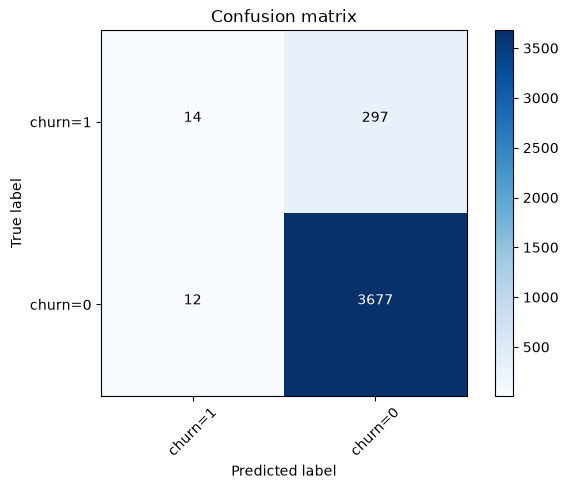

In [352]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')

## Classification Reports

In [353]:
print(classification_report(y_test , yhat))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3689
           1       0.54      0.05      0.08       311

    accuracy                           0.92      4000
   macro avg       0.73      0.52      0.52      4000
weighted avg       0.90      0.92      0.89      4000



## Logloss

In [354]:
from sklearn.metrics import log_loss
log_loss(y_test , yhat_prob)

0.2397268770942648